In [1]:
# import libraries and modules
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# setup path
sys.path.append(os.path.abspath('../'))
from src.order_book import calculate_volume_imbalance, approximate_order_flow

In [2]:
# load data and set index
df = pd.read_csv('../data/processed/spy_cleaned_1m.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'])
df.set_index('Datetime', inplace=True)

In [3]:
# approximate the buyer and seller volume profiles
buyer_vol, seller_vol = approximate_order_flow(df)

df['buyer_volume'] = buyer_vol
df['seller_volume'] = seller_vol

# calculate the rolling volume imbalance over a 30-minute window
df['rolling_buy_vol'] = df['buyer_volume'].rolling(30).sum()
df['rolling_sell_vol'] = df['seller_volume'].rolling(30).sum()

df['vol_imbalance'] = calculate_volume_imbalance(df['rolling_buy_vol'], df['rolling_sell_vol'])

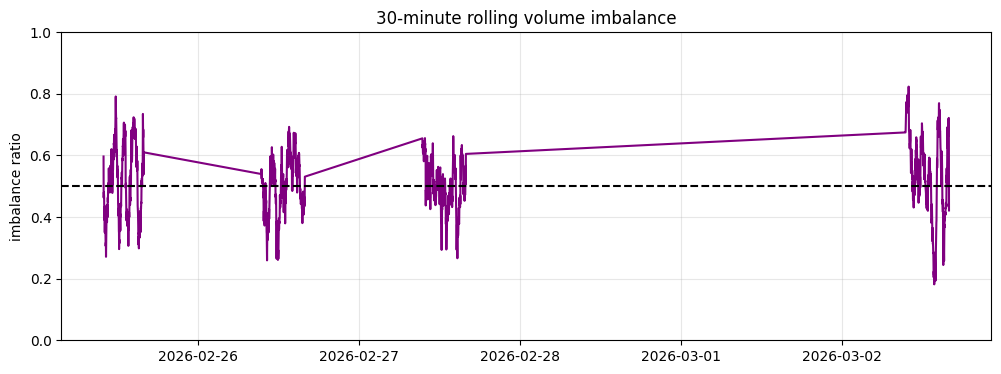

In [4]:
# plot the order flow imbalance
# values above 0.5 indicate buying pressure, below 0.5 indicate selling pressure
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['vol_imbalance'], color='purple')
plt.axhline(0.5, color='black', linestyle='--')

plt.title('30-minute rolling volume imbalance')
plt.ylabel('imbalance ratio')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()